In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./air_fryers_clean_brand_year.csv')
df.head() 

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


# **Question 1: What are the average unit costs and markups for each brand over the years?**

In [3]:
#Fit demand model

features = ['compact_share','dual_basket_share','oven_style_share','rotisserie_share','window_share']
y = df['log_brand_share']
brand_dummies = pd.get_dummies(df['brand'], prefix = 'brand', drop_first = True, dtype = int)
year_dummies = pd.get_dummies(df['year'].astype(str), prefix = 'year', drop_first = True, dtype = int)

X = pd.concat([df[['avg_price', 'avg_rating'] + features], brand_dummies, year_dummies], axis=1)

model = LinearRegression()
model.fit(X, y)
predicted_log_share = model.predict(X)
coef_table = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})

In [ ]:
#Q1 chart of unit costs and markups
price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0]
print(f'Price coefficient: {price_coef:.4f}')

results = df.copy()
results['predicted_log_share'] = predicted_log_share
results['demand_slope'] = price_coef * results['brand_share'] * (1 - results['brand_share'])
results['unit_cost'] = results['avg_price'] + results['brand_share'] / results['demand_slope']
results['markup'] = results['avg_price'] - results['unit_cost']
results['average_profit'] = results['brand_share'] * results['markup']

print(f'\nNegative unit costs: {(results["unit_cost"] < 0).any()}')
print()
print(results[['unit_cost','markup','average_profit']].describe().round(3))
results.groupby('brand')[['unit_cost', 'markup']].mean().round(2)

Price coefficient: -0.0377

Negative unit costs: False

       unit_cost  markup  average_profit
count     50.000  50.000          50.000
mean      93.102  29.704           3.156
std       51.696   2.616           2.616
min       22.003  26.567           0.019
25%       53.159  27.952           1.404
50%       70.038  28.813           2.265
75%      123.562  30.957           4.409
max      199.730  37.507          10.959


,unit_cost,markup
brand,,
chefman,61.57,29.37
cosori,86.28,27.98
cuisinart,194.90,29.05
dash,27.94,29.54
gowise usa,56.30,31.15
instant_pot,71.90,32.56
ninja,112.49,32.85
nuwave,109.05,27.97
oster,161.80,27.23


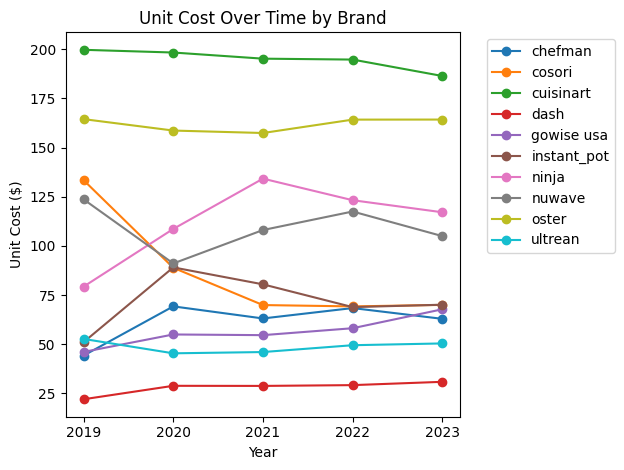

In [6]:
#Unit Cost over the years
plt.figure()
for brand in results['brand'].unique():
    sub = results[results['brand'] == brand].sort_values('year')
    plt.plot(sub['year'], sub['unit_cost'], marker='o', label=brand)
plt.title('Unit Cost Over Time by Brand')
plt.xlabel('Year')
plt.ylabel('Unit Cost ($)')
plt.xticks([2019, 2020, 2021, 2022, 2023])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

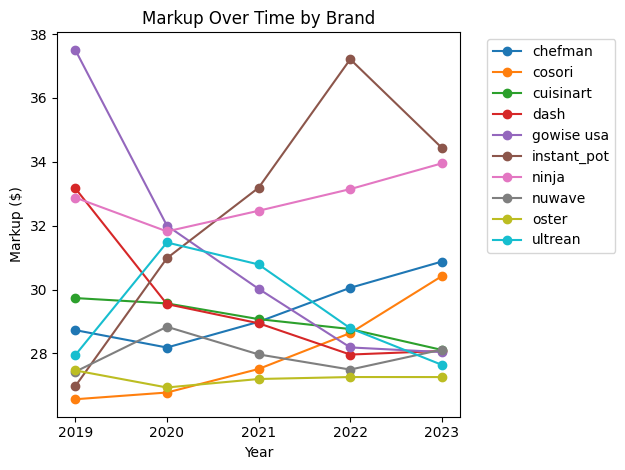

In [7]:
#Markup over the years
plt.figure()
for brand in results['brand'].unique():
    sub = results[results['brand'] == brand].sort_values('year')
    plt.plot(sub['year'], sub['markup'], marker='o', label=brand)
plt.title('Markup Over Time by Brand')
plt.xlabel('Year')
plt.ylabel('Markup ($)')
plt.xticks([2019, 2020, 2021, 2022, 2023])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Question 1 Answer:**
Average unit costs for each brand range from around $28 to roughly $195 with Cuisinart spending the most for producing each additional unit and Dash spending the least. In order from cheapest unit costs to highest unit costs Dash leads with $27.94, Ultrean follows close behind with $48.79, Chefman is next with $61.57, Instant Pot with $71.90, Cosori with $86.28, NuWave with $109.05, Ninja with $112.49, Oster with $161.80, and finally Cusinart with the highest per unit cost of $194.90. 

From a markup perspective, markups are similar and range from $27 to $33, which suggests these brands are profiting similar amounts for each unit sold. In order from smallest markup to largest, Oster has the lowest at $27.23, followed by Nuwave at $27.97, Cosori at $27.98, Cuisinart at $29.05, Ultrean at $29.33, Chefman at $29.37, Dash at $29.54, GoWise USA at $31.15, Instant Pot at $32.56, and finally Ninja with the highest markup at $32.85. This analysis highlights Ninja and Instant Pot as the brands with the highest markups which indicates that they are profiting more off each unit sold.

The variation in markups and unit costs are also displayed above in lineplots. The main trends observed from these are that unit costs are relatively stable over time for every brand, which indicates production costs did not meaningfully change over the period of 2019 to 2023. Additionally, markups are also relatively stable over time for some brands, but Instant Pot has been able to increase markup meaningfully and Go Wise USA has had falling markup. This is fairly consistent with the market analysis of price positioning conducted by the data analysts.

# **Question 2: Are any inferred unit costs negative? If so, what might that mean?**

In [10]:
print(f'Negative unit costs: {(results["unit_cost"] < 0).any()}')

Negative unit costs: False


**Question 2 Answer:** 
There are no negative inferred unit costs observed across brands. This makes practical sense because it means there is a production cost incurred by brands in order to produce additonal units. Even if a firm has significant economies of scale, unit costs fall as output increases, but these costs can only fall towards zero and can never be negative. 

If unit costs were negative in the model, this would call into question the veracity of the model since, as mentioned, it is not practically possible for these costs to actually be zero unless some sort of fraud was occurring in the firm. From a modeling perspective, unit costs are always positive because the price coefficient is negative, so the demand slope is also negative. Thus, the markup term is subtracted from price to produce a positive unit cost. If the unit cost was negative, this may have been caused by a positive price coefficient, which would make the demand slope positive, so the now positive markup term would push unit costs to be negative.

# **Question 3: Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?**

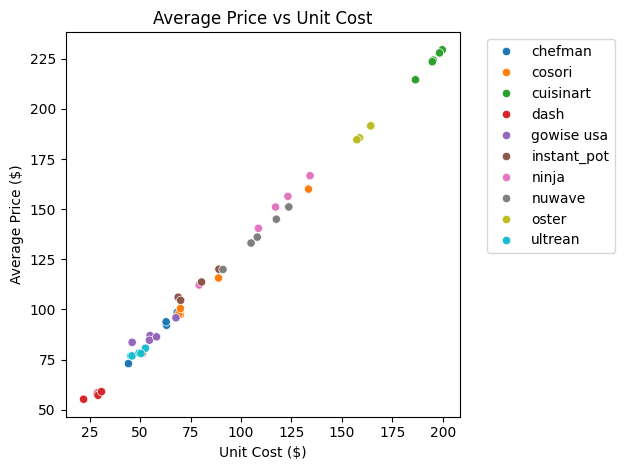

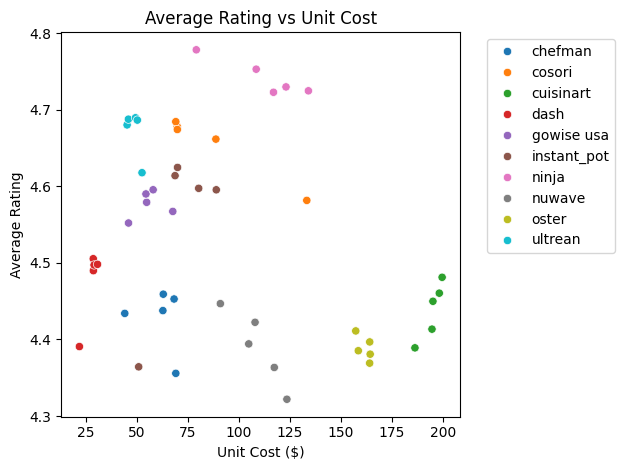

In [8]:
plt.figure()
sns.scatterplot(data=results, x='unit_cost', y='avg_price', hue='brand')
plt.title('Average Price vs Unit Cost')
plt.xlabel('Unit Cost ($)')
plt.ylabel('Average Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure()
sns.scatterplot(data=results, x='unit_cost', y='avg_rating', hue='brand')
plt.title('Average Rating vs Unit Cost')
plt.xlabel('Unit Cost ($)')
plt.ylabel('Average Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Question 3 Answer:**
Cuisinart has the highest average unit cost at $194.90 with Oster following it at $161.80. The average unit costs for the other brands are significantly lower than these two brands and they range from $27.94 to $112.49. 

The price vs. unit cost scatter plot shows a strong positive linear relationship between average price and unit cost. More expensive brands have proportionally higher unit costs with price always exceeding unit cost indicating every brand has a positive markup throughout the observation window. This is consistent within the findings from question 1.

From the plot of unit cost and average rating shown above, higher unit costs do not guarantee higher customer satisfaction. Cuisinart and Oster have the highest unit costs but medium ratings of roughly 4.44 and 4.39 respectively, while Ninja achieves the highest ratings of 4.74 at a mid-level unit cost of $112.49. Thus, more expensive products do not necessarily have higher consumer satisfaction in the air fryer market. This suggests that customer satisfaction is driven more by other factors, which could be brand investment and design decisions, rather than raw production cost. Overall, more expensive products do not have higher consumer satisfaction in the air fryer market.

**Question 4: Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.**

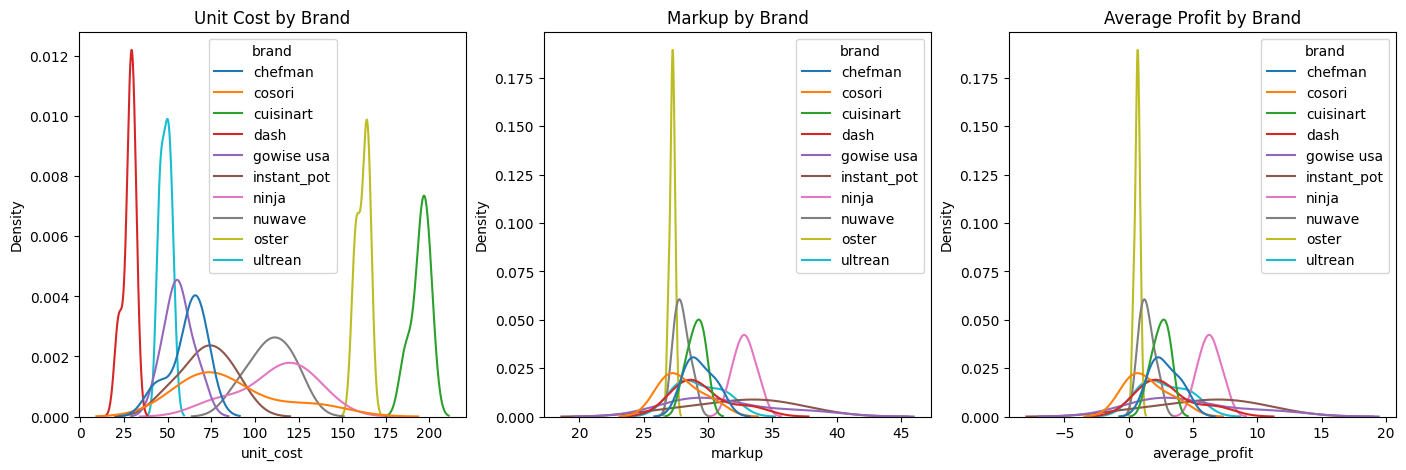

In [ ]:
#KDE plots hued by brand
fig, axes = plt.subplots(1, 3, figsize = (17, 5))
sns.kdeplot(data = results, x = 'unit_cost', hue = 'brand', ax = axes[0])
sns.kdeplot(data = results, x = 'markup', hue = 'brand', ax = axes[1])
sns.kdeplot(data = results, x = 'average_profit', hue = 'brand', ax = axes[2])

axes[0].set_title('Unit Cost by Brand')
axes[1].set_title('Markup by Brand')
axes[2].set_title('Average Profit by Brand')

plt.show()

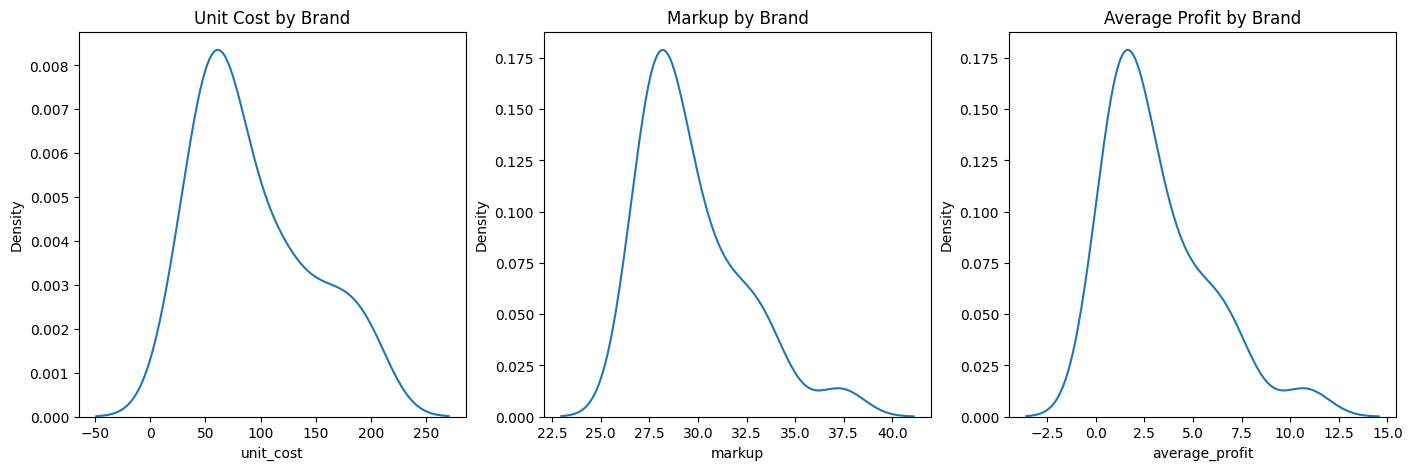

In [ ]:
#KDE plots with all brands combined
fig, axes = plt.subplots(1, 3, figsize = (17, 5))
sns.kdeplot(data = results, x = 'unit_cost', ax = axes[0])
sns.kdeplot(data = results, x = 'markup', ax = axes[1])
sns.kdeplot(data = results, x = 'average_profit', ax = axes[2])

axes[0].set_title('Unit Cost by Brand')
axes[1].set_title('Markup by Brand')
axes[2].set_title('Average Profit by Brand')

plt.show()

**Question 4 Answer:**
From the kde plots, it is visually clear there is a large spread in unit costs across brands. Each brand has a narrow individual distribution, indicating brands' unit costs are not varied significantly over time on a individual brand basis.

In terms of markups, all brands are tightly clustered between roughly $27 and $37. No brand has dramatically more pricing power than another, confirming that markups are relatively similar across the market.

Lastly, the average profit for most brands is clustered around \$1 with Ninja and Instant Pot having the rightmost distributions and being the most profitable on a share-weighted basis. 

**Question 5: Which brands have the highest share-weighted average profit?**

In [10]:
print(results.groupby('brand')['average_profit'].mean().sort_values(ascending=False).round(3))

brand
ninja          6.306
instant_pot    6.010
gowise usa     4.606
dash           2.994
chefman        2.821
ultrean        2.781
cuisinart      2.503
cosori         1.437
nuwave         1.423
oster          0.678
Name: average_profit, dtype: float64


**Question 5 Answer:**
Share weighted average profit measures the firm's market share relative to how much it is making per unit (markup). The product of these two factors comprises the average profit on a share weighted basis. This allows us to measure how profitable each brand is while accounting for the volume they are able to sell.

Ninja has the highest-share weighted average profit of 6.306, followed by Instant Pot at 6.010, and GoWise USA at 4.606. Each of these are the primary market leaders in profitability due to their high per unit markups and large market shares. Oster, NuWave, and Cosori are at share-weighted average profits of 0.678, 1.423, 1.437, respectively. This is not because their markups are low, all brands have similar markups, but their market shares are too small to generate meaningful share-weighted profit. This highlights the importance of capturing market share alongside having a sufficient markup to generate high share-weighted profit.